# 批归一化  
批归一化（Batch Normalization）是一种常用的神经网络优化技术，用于在神经网络训练过程中对每批输入进行归一化操作。它的主要目的是缓解梯度消失或梯度爆炸的问题，并且加速模型的收敛。在本节中，首先介绍批归一化的基本原理，然后通过实验观察其在神经网络训练过程中的重要作用。

## 1.批归一化原理

我们已经了解到，如果不缩放输入数据，则[权重优化](Notes\6.神经网络性能优化技术.ipynb)的速度很慢。这是由于当面临以下情况时，隐藏层的值可能会很高：

- 输入数据值高
- 权重值高
- 权重和输入的乘积很高  


任何一种情况都可能导致隐藏层具有较大输出值。隐藏层可以视为输出层的输入层。因此，当隐藏层值也很大时，同样会导致网络优化缓慢。接下来，我们考虑当输入值非常小，Sigmoid 输出随权重的变化情况：  

| 输入  | 权重   | Sigmoid 输出 |
|-------|--------|--------------|
| 0.01  | 0.00001| 0.5          |
| 0.01  | 0.00001| 0.5          |
| 0.01  | 0.001  | 0.5          |
| 0.01  | 0.01   | 0.5          |
| 0.01  | 0.1    | 0.5          |
| 0.01  | 0.2    | 0.5          |
| 0.01  | 0.3    | 0.501        |
| 0.01  | 0.4    | 0.501        |
| 0.01  | 0.5    | 0.501        |
| 0.01  | 0.6    | 0.501        |
| 0.01  | 0.7    | 0.502        |
| 0.01  | 0.8    | 0.502        |
| 0.01  | 0.9    | 0.502        |
| 0.01  | 1      | 0.502        |

当输入值非常小时，Sigmoid 输出的变化幅度较小，从而会对权重值产生较大变化。此外，我们已经看到较大的输入值会对训练准确率有负面影响，这表明输入值既不能过小，也不能过大值。

除了输入值外，当前网络层可以视为下一网络层的输入层，因此同样可能会出现过大或过小的情况，从而导致网络优化缓慢。我们已经了解到，当输入值很高时，我们将执行缩放以减小输入值。批归一化是用于在神经网络中对每个批次的输入数据进行归一化处理，它可以加速模型的训练，提高模型的稳定性和泛化能力。批归一化的算法流程如下：

- 对于每个批次的输入数据，计算其均值和方差。可以通过求取批次内样本的均值和方差的无偏估计来计算
- 对于每个特征，将其均值归一化为0，方差归一化为1.这可以通过减去均值并除以标准差来完成
- 引入可学习的参数 γ \gammaγ 和 β \betaβ，用于缩放和平移归一化后的数据。这两个参数允许模型自动学习适当的尺度和偏移，以便更好地拟合数据

批归一化使用以下公式缩放每个批次的输入数据值：    
\begin{align*}
\text{Batch mean } \mu_B &= \frac{1}{m} \sum_{i=1}^{m} x_i \\
\text{Batch Variance } \sigma_B^2 &= \frac{1}{m} \sum_{i=1}^{m} (x_i - \mu_B)^2 \\
\text{Normalized input } \bar{x}_i &= \frac{(x_i - \mu_B)}{\sqrt{\sigma_B^2 + \epsilon}} \\
\text{Batch normalized input } &= \gamma \bar{x}_i + \beta
\end{align*}

通过每个输入数据减去批数据输入的平均值，然后将其除以批数据方差，可以将一个节点处所有批数据点归一化到一个固定范围，通过引入 γ 和 β 参数，可以让网络识别最佳归一化参数。

批归一化在训练和预测阶段的计算方式是不同的，在训练阶段，批归一化使用当前批次的均值和方差进行归一化；而在预测阶段，使用训练过程中计算得到的整体均值和方差来归一化输入数据。

## 2.批归一化的优势  
- 加速模型收敛：通过减少内部协变量偏移( Internal Covariate Shift)，即每层输入分布的变化，批归一化有助于加快模型的收敛速度。这意味着我们可以使用更大的学习率，并在更短的时间内达到更好的性能。  
- 提高模型稳定性：批归一化可以减少网络对输入数据中小的批量统计变化的敏感性，从而使得模型更加稳定。这有助于减轻梯度消失或梯度爆炸等训练过程中的问题。  
- 增强模型泛化能力：批归一化具有正则化的效果，类似于 Dropout 等常用的正则化技术。它可以稍微减少对其他正则化方法的依赖，并提高模型的泛化能力。

## 3.批归一化对模型训练的影响  
为了了解批归一化对模型训练的影响，观察使用以下设定时，训练和验证数据集的损失和准确率值，以及隐藏层值的分布：  
- 未使用批归一化，且输入值较小
- 使用批归一化，且输入值较小  

### 3.1 未使用批归一化，且输入值较小  
我们通常将输入数据缩放到 0 到 1，在本节中，我们将更进一步将其缩放到 0 到 0.0001 之间，以便了解缩放数据的影响。我们已经知道，即使权重值变化很大，小的输入值也无法改变 Sigmoid 值。​
为了缩放输入数据集，我们通常在 FMNISTDataset 类中执行缩放操作，通过将输入像素值除以 (255*10000) 来缩小输入像素值的范围，将输入值的范围缩放至 0 到 0.0001：

In [3]:
import torch
from torch.utils.data import Dataset
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x =  x.float() / (255*10000)
        x = x.view(-1, 28*28)
        self.x = x
        self.y = y
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        x, y = self.x[idx], self.y[idx]
        return x.to(device), y.to(device)

重新定义get_model()函数，以便获取模型的预测以及隐藏层的值：

In [5]:
 
def get_model():
    class neuralnet(nn.Module):
        def __init__(self):
            super(neuralnet, self).__init__()
            self.input_to_hidden_layer = nn.Linear(28*28, 1000)
            self.hidden_layer_activation = nn.ReLU()
            self.hidden_to_output_layer = nn.Linear(1000, 10)
        def forward(self, x):
            x = self.input_to_hidden_layer(x)
            x1 = self.hidden_layer_activation(x)
            x2 = self.hidden_to_output_layer(x1)
            return x2, x1
    model = neuralnet().to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
    return model, loss_fn, optimizer

在以上代码中，定义了神经网络类，它返回输出层值 (x2) 和隐藏层的激活值 (x1)。

由于修改后的 get_model() 会返回两个输出，我们同样需要修改 train_batch() 和 val_loss() 函数，在这两个函数中我们只需要获取输出层的值，而无需隐藏层值。由于输出层值位于模型返回的第 0 个索引中，我们需要修改函数使其仅获取第 0 个预测索引：

In [ ]:
 
def train_batch(x, y, model, loss_fn, optimizer):
    prediction = model(x)[0]
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    return batch_loss.item()

def accuracy(x, y, model):
    with torch.no_grad():
        prediction = model(x)[0]
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

训练模型后，得到训练和验证数据集中的准确率和损失值在训练过程中的变化：

Epoch 1/100 Train Loss: 2.3021 Val Loss: 2.3011 Train Acc: 0.1059 Val Acc: 0.1000
Epoch 2/100 Train Loss: 2.2996 Val Loss: 2.2970 Train Acc: 0.1446 Val Acc: 0.2666
Epoch 3/100 Train Loss: 2.2927 Val Loss: 2.2869 Train Acc: 0.2668 Val Acc: 0.2731
Epoch 4/100 Train Loss: 2.2786 Val Loss: 2.2684 Train Acc: 0.3453 Val Acc: 0.3605
Epoch 5/100 Train Loss: 2.2553 Val Loss: 2.2405 Train Acc: 0.3807 Val Acc: 0.3458
Epoch 6/100 Train Loss: 2.2226 Val Loss: 2.2033 Train Acc: 0.3662 Val Acc: 0.3770
Epoch 7/100 Train Loss: 2.1812 Val Loss: 2.1583 Train Acc: 0.4237 Val Acc: 0.4405
Epoch 8/100 Train Loss: 2.1332 Val Loss: 2.1079 Train Acc: 0.4436 Val Acc: 0.3966
Epoch 9/100 Train Loss: 2.0807 Val Loss: 2.0539 Train Acc: 0.4112 Val Acc: 0.4145
Epoch 10/100 Train Loss: 2.0260 Val Loss: 1.9990 Train Acc: 0.4346 Val Acc: 0.4184
Epoch 11/100 Train Loss: 1.9709 Val Loss: 1.9444 Train Acc: 0.4329 Val Acc: 0.4157
Epoch 12/100 Train Loss: 1.9167 Val Loss: 1.8911 Train Acc: 0.4355 Val Acc: 0.4539
Epoch 13/100 

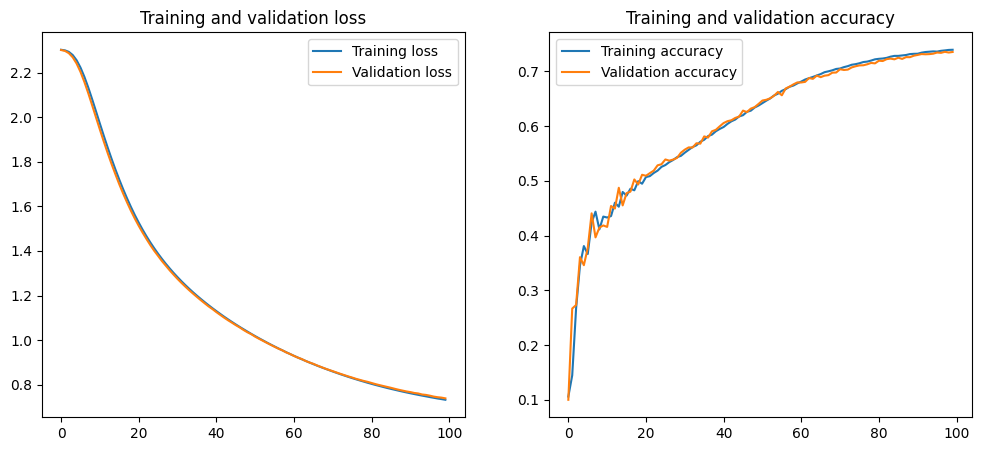

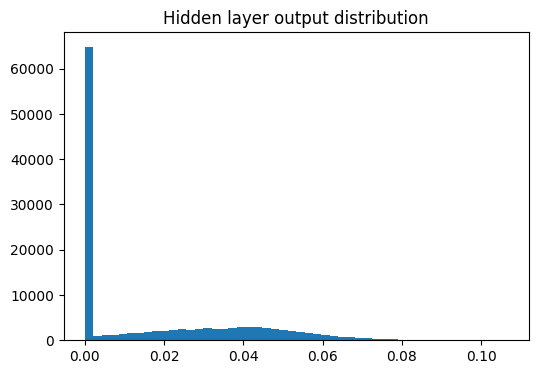

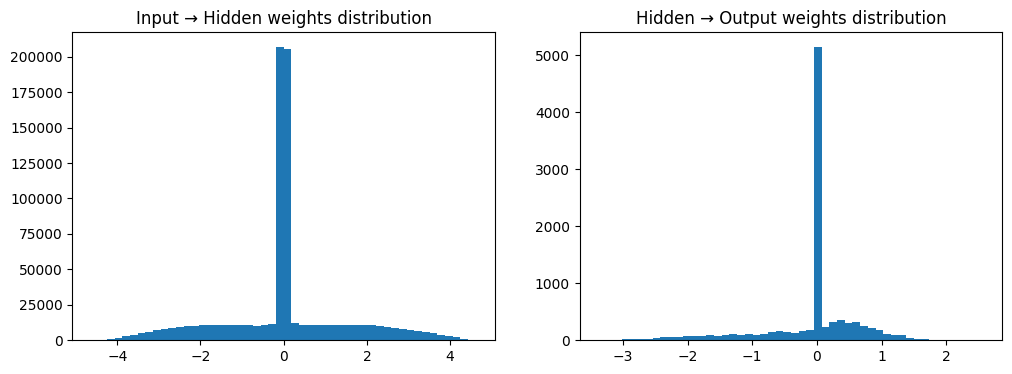

In [10]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

device = "cpu"

class FMNISTDataset(torch.utils.data.Dataset):
    def __init__(self, x, y):
        x = x.float() / (255*10000)   
        x = x.view(-1, 28*28)
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        x, y = self.x[idx], self.y[idx]
        return x.to(device), y.to(device)


def get_model():
    class neuralnet(nn.Module):
        def __init__(self):
            super(neuralnet, self).__init__()
            self.input_to_hidden_layer = nn.Linear(28*28, 1000)
            self.hidden_layer_activation = nn.ReLU()
            self.hidden_to_output_layer = nn.Linear(1000, 10)

        def forward(self, x):
            x = self.input_to_hidden_layer(x)
            x1 = self.hidden_layer_activation(x)
            x2 = self.hidden_to_output_layer(x1)
            return x2, x1

    model = neuralnet().to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
    return model, loss_fn, optimizer


def train_batch(x, y, model, loss_fn, optimizer):
    prediction = model(x)[0]
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    return batch_loss.item()


def accuracy(x, y, model):
    with torch.no_grad():
        prediction = model(x)[0]
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

train_raw = datasets.FashionMNIST("./data", train=True, download=True, transform=ToTensor())
val_raw = datasets.FashionMNIST("./data", train=False, download=True, transform=ToTensor())

train_ds = FMNISTDataset(train_raw.data, train_raw.targets)
val_ds = FMNISTDataset(val_raw.data, val_raw.targets)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)

model, loss_fn, optimizer = get_model()

epochs = 100

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):

    # ---------- 训练 ----------
    model.train()
    batch_losses = []
    batch_acc = []

    for x, y in train_loader:
        loss = train_batch(x, y, model, loss_fn, optimizer)
        batch_losses.append(loss)
        batch_acc.extend(accuracy(x, y, model))

    train_losses.append(np.mean(batch_losses))
    train_accuracies.append(np.mean(batch_acc))


    # ---------- 验证 ----------
    model.eval()
    val_batch_losses = []
    val_batch_acc = []

    with torch.no_grad():
        for x, y in val_loader:
            prediction = model(x)[0]
            loss = loss_fn(prediction, y)
            val_batch_losses.append(loss.item())
            val_batch_acc.extend(accuracy(x, y, model))

    val_losses.append(np.mean(val_batch_losses))
    val_accuracies.append(np.mean(val_batch_acc))

    print(f"Epoch {epoch+1}/{epochs} "
          f"Train Loss: {train_losses[-1]:.4f} "
          f"Val Loss: {val_losses[-1]:.4f} "
          f"Train Acc: {train_accuracies[-1]:.4f} "
          f"Val Acc: {val_accuracies[-1]:.4f}")
          
# 绘制 Loss / Accuracy 曲线


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Training loss")
plt.plot(val_losses, label="Validation loss")
plt.title("Training and validation loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accuracies, label="Training accuracy")
plt.plot(val_accuracies, label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()

plt.show()


model.eval()
with torch.no_grad():
    sample_x, _ = next(iter(val_loader))
    _, hidden_output = model(sample_x)

hidden_values = hidden_output.cpu().numpy().flatten()

plt.figure(figsize=(6,4))
plt.hist(hidden_values, bins=50)
plt.title("Hidden layer output distribution")
plt.show()

input_hidden_weights = model.input_to_hidden_layer.weight.detach().cpu().numpy().flatten()
hidden_output_weights = model.hidden_to_output_layer.weight.detach().cpu().numpy().flatten()

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(input_hidden_weights, bins=50)
plt.title("Input → Hidden weights distribution")

plt.subplot(1,2,2)
plt.hist(hidden_output_weights, bins=50)
plt.title("Hidden → Output weights distribution")

plt.show()


可以看到，即使在 100 个 epoch 之后，模型也没有获得优异性能(只有大约 73% 的验证准确率)，而在以上部分中，模型在 10 个 epoch 内的验证数据集上可以获得大约 90% 的准确率。

通过探索隐藏值的分布以及参数分布来了解当输入值范围较小时，模型性能不佳的原因：

第一个分布表示隐藏层中值的分布(可以看到这些值的范围非常小)，此外，由于输入和隐藏层值的范围都非常小，权重(包括将输入连接到隐藏层的权重和将隐藏层连接到输出层的权重)必须有大幅度的变化。

我们已经了解了当输入值的范围非常小时，网络就不能很好地训练，接下来我们将学习批归一化如何帮助增大隐藏层内的值范围。

### 3.2使用批归一化，且输入值较小  
在本节中，我们在上一小节的代码基础上增加批归一化，修改后的 get_model() 函数如下：

In [11]:
from torch.optim import Adam, SGD
import torch
import torch.nn as nn

def get_model():
    class neuralnet(nn.Module):
        def __init__(self):
            super().__init__()
            self.input_to_hidden_layer = nn.Linear(28*28, 1000)
            self.batch_norm = nn.BatchNorm1d(1000)
            self.hidden_layer_activation = nn.ReLU()
            self.hidden_to_output_layer = nn.Linear(1000, 1)

        def forward(self, x):
            x = self.input_to_hidden_layer(x)
            x = self.batch_norm(x)
            x1 = self.hidden_layer_activation(x)
            x2 = self.hidden_to_output_layer(x1)
            return x2, x1
        
    model = neuralnet().to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=0.0001)
    return model, loss_fn, optimizer

在以上代码中，我们声明了一个执行归一化（nn.BatchNormld)的变量（batch_norm), 由于隐藏层中每个图像的输出维度为1000，因此执行nn.BatchNormld(1000)。此外，在向前传播方法forward()中，在ReLU激活之前通过批归一化传递隐藏层值的输出。  
训练和验证数据集的准确率和损失随时间的变化如下：

Epoch 1/100 Train Loss: 1.5811 Val Loss: 1.0203 Train Acc: 0.6068 Val Acc: 0.6853
Epoch 2/100 Train Loss: 0.8244 Val Loss: 0.7271 Train Acc: 0.7329 Val Acc: 0.7432
Epoch 3/100 Train Loss: 0.6607 Val Loss: 0.6339 Train Acc: 0.7646 Val Acc: 0.7689
Epoch 4/100 Train Loss: 0.5920 Val Loss: 0.5814 Train Acc: 0.7863 Val Acc: 0.7871
Epoch 5/100 Train Loss: 0.5479 Val Loss: 0.5486 Train Acc: 0.8045 Val Acc: 0.8024
Epoch 6/100 Train Loss: 0.5182 Val Loss: 0.5280 Train Acc: 0.8142 Val Acc: 0.8073
Epoch 7/100 Train Loss: 0.4954 Val Loss: 0.5050 Train Acc: 0.8225 Val Acc: 0.8165
Epoch 8/100 Train Loss: 0.4761 Val Loss: 0.4884 Train Acc: 0.8300 Val Acc: 0.8226
Epoch 9/100 Train Loss: 0.4623 Val Loss: 0.4776 Train Acc: 0.8347 Val Acc: 0.8270
Epoch 10/100 Train Loss: 0.4504 Val Loss: 0.4695 Train Acc: 0.8398 Val Acc: 0.8313
Epoch 11/100 Train Loss: 0.4392 Val Loss: 0.4609 Train Acc: 0.8427 Val Acc: 0.8332
Epoch 12/100 Train Loss: 0.4313 Val Loss: 0.4532 Train Acc: 0.8464 Val Acc: 0.8355
Epoch 13/100 

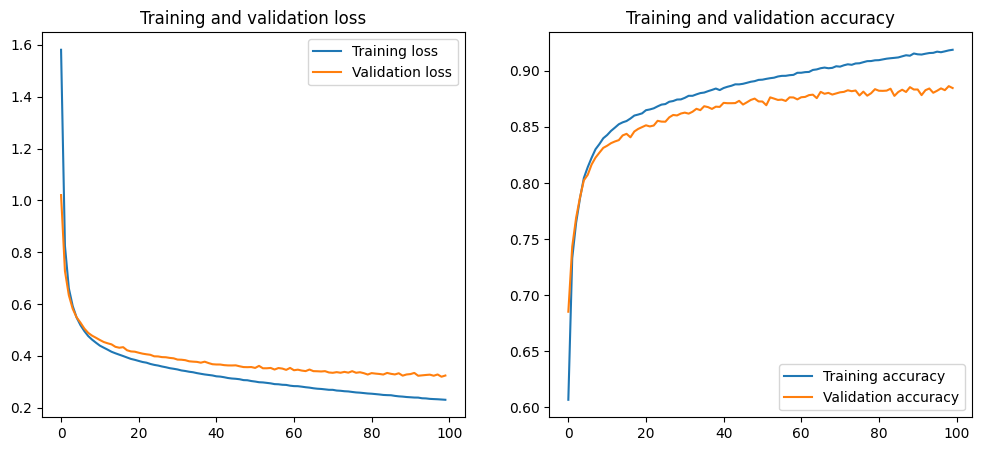

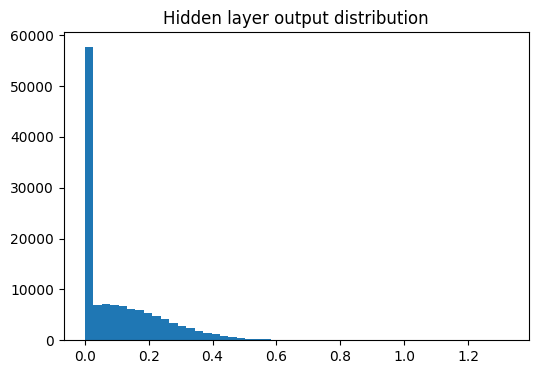

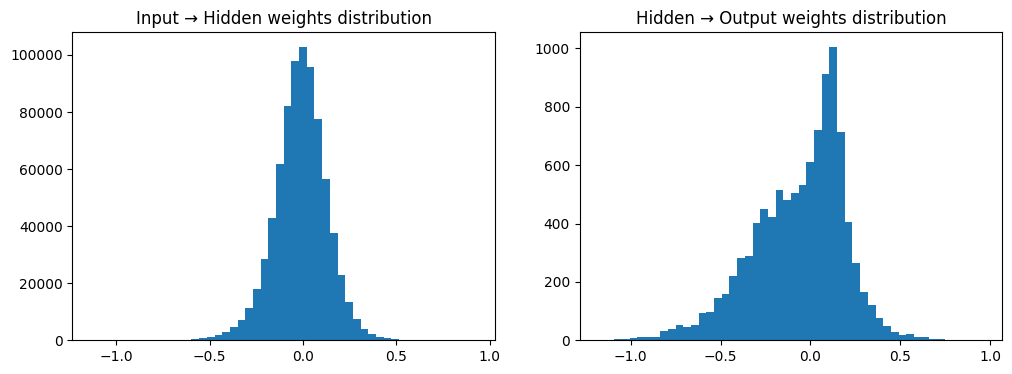

In [16]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

device = "cpu"

class FMNISTDataset(torch.utils.data.Dataset):
    def __init__(self, x, y):
        x = x.float() / (255*10000)   
        x = x.view(-1, 28*28)
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        x, y = self.x[idx], self.y[idx]
        return x.to(device), y.to(device)


def get_model():
    class neuralnet(nn.Module):
        def __init__(self):
            super().__init__()
            self.input_to_hidden_layer = nn.Linear(28*28, 1000)
            self.batch_norm = nn.BatchNorm1d(1000)
            self.hidden_layer_activation = nn.ReLU()
            self.hidden_to_output_layer = nn.Linear(1000, 10)

        def forward(self, x):
            x = self.input_to_hidden_layer(x)
            x = self.batch_norm(x)
            x1 = self.hidden_layer_activation(x)
            x2 = self.hidden_to_output_layer(x1)
            return x2, x1
        
    model = neuralnet().to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=0.0001)
    return model, loss_fn, optimizer


def train_batch(x, y, model, loss_fn, optimizer):
    prediction = model(x)[0]
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    return batch_loss.item()


def accuracy(x, y, model):
    with torch.no_grad():
        prediction = model(x)[0]
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

train_raw = datasets.FashionMNIST("./data", train=True, download=True, transform=ToTensor())
val_raw = datasets.FashionMNIST("./data", train=False, download=True, transform=ToTensor())

train_ds = FMNISTDataset(train_raw.data, train_raw.targets)
val_ds = FMNISTDataset(val_raw.data, val_raw.targets)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)

model, loss_fn, optimizer = get_model()

epochs = 100

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):

    # ---------- 训练 ----------
    model.train()
    batch_losses = []
    batch_acc = []

    for x, y in train_loader:
        loss = train_batch(x, y, model, loss_fn, optimizer)
        batch_losses.append(loss)
        batch_acc.extend(accuracy(x, y, model))

    train_losses.append(np.mean(batch_losses))
    train_accuracies.append(np.mean(batch_acc))


    # ---------- 验证 ----------
    model.eval()
    val_batch_losses = []
    val_batch_acc = []

    with torch.no_grad():
        for x, y in val_loader:
            prediction = model(x)[0]
            loss = loss_fn(prediction, y)
            val_batch_losses.append(loss.item())
            val_batch_acc.extend(accuracy(x, y, model))

    val_losses.append(np.mean(val_batch_losses))
    val_accuracies.append(np.mean(val_batch_acc))

    print(f"Epoch {epoch+1}/{epochs} "
          f"Train Loss: {train_losses[-1]:.4f} "
          f"Val Loss: {val_losses[-1]:.4f} "
          f"Train Acc: {train_accuracies[-1]:.4f} "
          f"Val Acc: {val_accuracies[-1]:.4f}")
          
# 绘制 Loss / Accuracy 曲线


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Training loss")
plt.plot(val_losses, label="Validation loss")
plt.title("Training and validation loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accuracies, label="Training accuracy")
plt.plot(val_accuracies, label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()

plt.show()


model.eval()
with torch.no_grad():
    sample_x, _ = next(iter(val_loader))
    _, hidden_output = model(sample_x)

hidden_values = hidden_output.cpu().numpy().flatten()

plt.figure(figsize=(6,4))
plt.hist(hidden_values, bins=50)
plt.title("Hidden layer output distribution")
plt.show()

input_hidden_weights = model.input_to_hidden_layer.weight.detach().cpu().numpy().flatten()
hidden_output_weights = model.hidden_to_output_layer.weight.detach().cpu().numpy().flatten()

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(input_hidden_weights, bins=50)
plt.title("Input → Hidden weights distribution")

plt.subplot(1,2,2)
plt.hist(hidden_output_weights, bins=50)
plt.title("Hidden → Output weights distribution")

plt.show()

可以看到，进行批归一化时，隐藏层值的分布更大，而连接隐藏层和输出层的权重分布更小，模型的训练结果与较优。批归一化在训练深度神经网络时极为有效，它可以帮助模型避免因梯度变得太小而无法更新权重的问题。

## 3.3使用批归一化，且输入值较大  
为了进一步了解批归一化，在上一小节的代码基础上修改输入数据范围，修改后如下：

In [17]:
class FMNISTDataset(torch.utils.data.Dataset):
    def __init__(self, x, y):
        x = x.float() / (255.)   
        x = x.view(-1, 28*28)
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        x, y = self.x[idx], self.y[idx]
        return x.to(device), y.to(device)

训练模型后，得到训练和验证数据集中的准确率和损失值在训练过程中的变化：

Epoch 1/100 Train Loss: 0.5300 Val Loss: 0.4191 Train Acc: 0.8252 Val Acc: 0.8527
Epoch 2/100 Train Loss: 0.3668 Val Loss: 0.3714 Train Acc: 0.8753 Val Acc: 0.8678
Epoch 3/100 Train Loss: 0.3254 Val Loss: 0.3585 Train Acc: 0.8892 Val Acc: 0.8705
Epoch 4/100 Train Loss: 0.2969 Val Loss: 0.3641 Train Acc: 0.8986 Val Acc: 0.8693
Epoch 5/100 Train Loss: 0.2734 Val Loss: 0.3282 Train Acc: 0.9074 Val Acc: 0.8829
Epoch 6/100 Train Loss: 0.2560 Val Loss: 0.3244 Train Acc: 0.9149 Val Acc: 0.8837
Epoch 7/100 Train Loss: 0.2379 Val Loss: 0.3120 Train Acc: 0.9208 Val Acc: 0.8883
Epoch 8/100 Train Loss: 0.2229 Val Loss: 0.3133 Train Acc: 0.9261 Val Acc: 0.8866
Epoch 9/100 Train Loss: 0.2106 Val Loss: 0.3203 Train Acc: 0.9315 Val Acc: 0.8844
Epoch 10/100 Train Loss: 0.1980 Val Loss: 0.3077 Train Acc: 0.9371 Val Acc: 0.8931
Epoch 11/100 Train Loss: 0.1854 Val Loss: 0.3162 Train Acc: 0.9414 Val Acc: 0.8888
Epoch 12/100 Train Loss: 0.1743 Val Loss: 0.3171 Train Acc: 0.9461 Val Acc: 0.8888
Epoch 13/100 

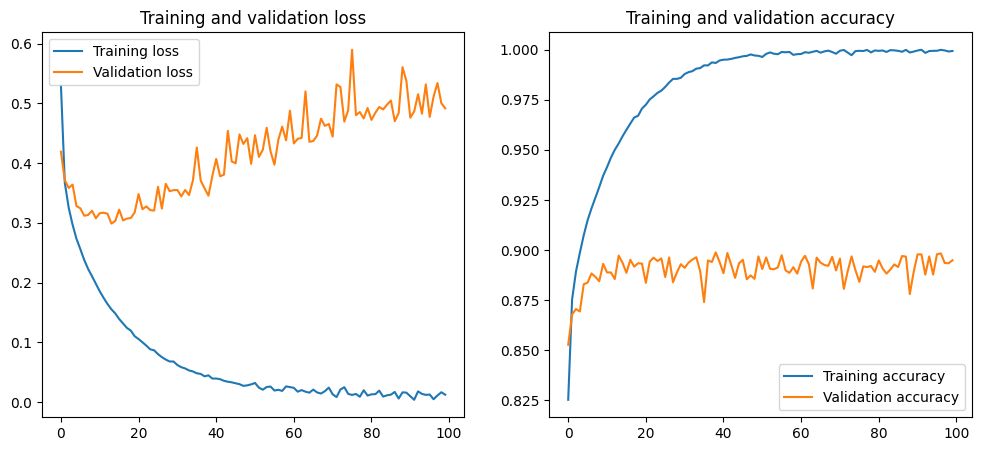

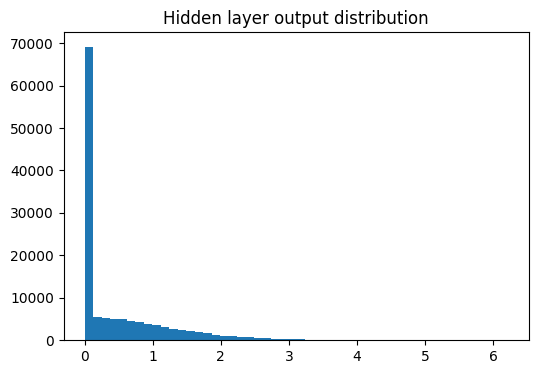

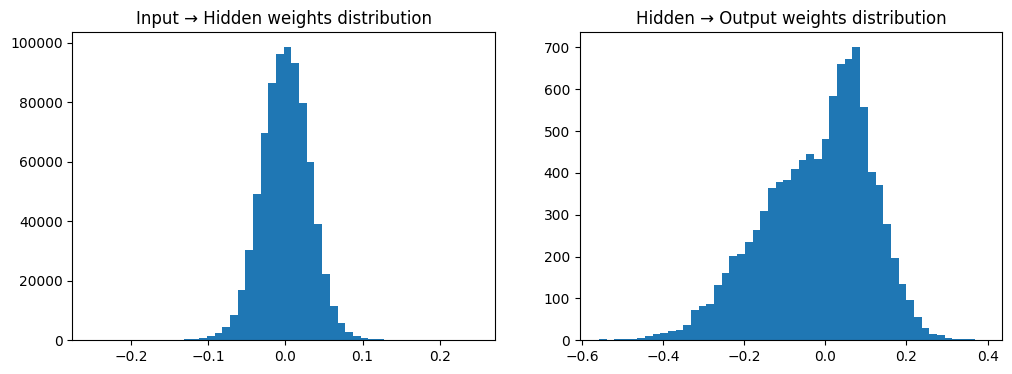

In [18]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

device = "cpu"

class FMNISTDataset(torch.utils.data.Dataset):
    def __init__(self, x, y):
        x = x.float() / (255.)   
        x = x.view(-1, 28*28)
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        x, y = self.x[idx], self.y[idx]
        return x.to(device), y.to(device)


def get_model():
    class neuralnet(nn.Module):
        def __init__(self):
            super().__init__()
            self.input_to_hidden_layer = nn.Linear(28*28, 1000)
            self.batch_norm = nn.BatchNorm1d(1000)
            self.hidden_layer_activation = nn.ReLU()
            self.hidden_to_output_layer = nn.Linear(1000, 10)

        def forward(self, x):
            x = self.input_to_hidden_layer(x)
            x = self.batch_norm(x)
            x1 = self.hidden_layer_activation(x)
            x2 = self.hidden_to_output_layer(x1)
            return x2, x1
        
    model = neuralnet().to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=0.0001)
    return model, loss_fn, optimizer


def train_batch(x, y, model, loss_fn, optimizer):
    prediction = model(x)[0]
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    return batch_loss.item()


def accuracy(x, y, model):
    with torch.no_grad():
        prediction = model(x)[0]
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

train_raw = datasets.FashionMNIST("./data", train=True, download=True, transform=ToTensor())
val_raw = datasets.FashionMNIST("./data", train=False, download=True, transform=ToTensor())

train_ds = FMNISTDataset(train_raw.data, train_raw.targets)
val_ds = FMNISTDataset(val_raw.data, val_raw.targets)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)

model, loss_fn, optimizer = get_model()

epochs = 100

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):

    # ---------- 训练 ----------
    model.train()
    batch_losses = []
    batch_acc = []

    for x, y in train_loader:
        loss = train_batch(x, y, model, loss_fn, optimizer)
        batch_losses.append(loss)
        batch_acc.extend(accuracy(x, y, model))

    train_losses.append(np.mean(batch_losses))
    train_accuracies.append(np.mean(batch_acc))


    # ---------- 验证 ----------
    model.eval()
    val_batch_losses = []
    val_batch_acc = []

    with torch.no_grad():
        for x, y in val_loader:
            prediction = model(x)[0]
            loss = loss_fn(prediction, y)
            val_batch_losses.append(loss.item())
            val_batch_acc.extend(accuracy(x, y, model))

    val_losses.append(np.mean(val_batch_losses))
    val_accuracies.append(np.mean(val_batch_acc))

    print(f"Epoch {epoch+1}/{epochs} "
          f"Train Loss: {train_losses[-1]:.4f} "
          f"Val Loss: {val_losses[-1]:.4f} "
          f"Train Acc: {train_accuracies[-1]:.4f} "
          f"Val Acc: {val_accuracies[-1]:.4f}")
          
# 绘制 Loss / Accuracy 曲线


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Training loss")
plt.plot(val_losses, label="Validation loss")
plt.title("Training and validation loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accuracies, label="Training accuracy")
plt.plot(val_accuracies, label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()

plt.show()


model.eval()
with torch.no_grad():
    sample_x, _ = next(iter(val_loader))
    _, hidden_output = model(sample_x)

hidden_values = hidden_output.cpu().numpy().flatten()

plt.figure(figsize=(6,4))
plt.hist(hidden_values, bins=50)
plt.title("Hidden layer output distribution")
plt.show()

input_hidden_weights = model.input_to_hidden_layer.weight.detach().cpu().numpy().flatten()
hidden_output_weights = model.hidden_to_output_layer.weight.detach().cpu().numpy().flatten()

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(input_hidden_weights, bins=50)
plt.title("Input → Hidden weights distribution")

plt.subplot(1,2,2)
plt.hist(hidden_output_weights, bins=50)
plt.title("Hidden → Output weights distribution")

plt.show()

---

| 情况 | 输入值 | 使用 BN | 优势 | 劣势 / 限制 |
| :--- | :--- | :--- | :--- | :--- |
| 1 | 大 | 是 | 稳定梯度，避免爆炸/消失，加速收敛 | 几乎无劣势 |
| 2 | 小 | 是 | 轻微增强稳定性，轻微正则化 | 对收敛速度提升不明显 |
| 3 | 小 | 否 | 简单，训练仍可进行 | 深层网络可能不稳定，无正则化 |

## 小结  
批归一化是一种通过标准化神经网络层的输入数据，加速模型训练并提高泛化能力的技术。它在深度学习中广泛应用，是构建高效、稳定的神经网络模型的重要方法。本节介绍了批归一化的基本概念及其优点，并通过实战了解了批归一化对模型训练的影响。